# Q11. How well does a one-hour Evo2 7B LoRA run predict missense pathogenicity?

Train **rank-8 LoRA in the final Hyena mixer (block 30)** and a linear classifier under a one-hour budget on the prepared H100. Keep every original backbone weight frozen. This user-authorized **partial epoch** uses a seeded shuffle of Q1's complete training pool and evaluates its complete frozen validation partition.

[Workflow](src/q11.py) · [GPU implementation](src/q11_backend.py) · [Dependencies](../requirements.txt) · [Setup](../README.md#setup).

Use **Gamow** and run all cells in order. Inputs, pinned model and BioNeMo environment are prepared automatically when missing; initial downloads/installation are outside the one-hour target. Expected hardware: one 80 GB H100, about 128 GB host RAM. Artifacts stay in `results/q11/`; external inputs stay in `data/`.

In [1]:
from src import q11

## Frozen inputs and shorter-context audits

Keep all **46,888 training and 17,927 validation variants** from the frozen 6 July 2026 ClinVar missense cohort. `clinvar-test.vcf` is development validation, without an untouched test stage. Verify source/VCF checksums, labels, inherited assignments, genes, loci, components and original sequence separation before fitting.

Each GRCh38 allele begins with its frozen 1,024-base context. Select the lexicographically smaller forward/reverse-complement **pair**, then crop **512 bases around the substitution**, with 256 bases before it. This gives one reproducible, strand-invariant orientation for both alleles. Check every reference and alternate crop for identical/reverse-complement sequences across splits. Crops remain inside the audited genomic intervals; stop on overlap.

Pool final-block activations over positions, concatenate reference and alternate-minus-reference vectors, and normalize each half by its own per-example RMS (epsilon 1e-6). The resulting 8,192 features contain DNA only; normalization has no learned statistics.

In [2]:
inputs = q11.prepare_inputs()

Verified 46,888 training / 17,927 validation variants.


## Pinned model and budget

Use Q10's pinned `arcinstitute/savanna_evo2_7b_base` checkpoint and BioNeMo conversion. [Arc's training guidance](https://github.com/ArcInstitute/evo2#training-and-finetuning) and the [pinned BioNeMo tutorial](https://github.com/NVIDIA-BioNeMo/bionemo-recipes/blob/ca16c2acf9bf813d020b6d1e2d4e1240cfef6a69/docs/docs/user-guide/examples/bionemo-evo2/fine-tuning-tutorial.ipynb) document the backend.

Attach pinned NeMo LoRA wrappers only to `decoder.layers.30.mixer.dense_projection` and `decoder.layers.30.mixer.dense`: rank **8**, alpha **16**, dropout **0**, Xavier A and zero B. All original tensors, including attention block 31, remain frozen. Earlier archived probes found block 31 numerically inactive in this BF16 configuration; the new adapter checks must pass independently.

Seed **42**; batches of **32 variants**; at most **768 updates / 24,576 variants**. Stop earlier at an optimizer boundary after **30 minutes** of training or when needed to reserve full validation and reporting time. Estimate validation duration from training-only throughput probes, add a 30% margin and four minutes for reporting. No baseline feature extraction or hyperparameter search.

Use BF16 backbone/adapters, FP32 pooling/head, FP32 AdamW master weights and accumulation, learning rates **1e-4**, weight decay **0.01**, gradient clipping **1.0**, and training-pool balanced class weights. Initialize the head with seeded PyTorch defaults and train it jointly with the adapters.

In [3]:
protocol = q11.establish_environment()

probe: log → notebooks/results/q9/environment/probe.log


Existing BioNeMo environment passed its import and CUDA checks.


## Preflight, partial epoch and full validation

Training-only probes verify source-to-conversion tensors, A/B/A repeatability, strand invariance, batched feature equivalence, zero-adapter equivalence, finite gradients, actual adapter/head updates and unchanged original backbone weights. Probe updates are restored. When B starts at zero, A's first gradient is zero; all adapter matrices must receive nonzero gradients across later probe steps.

Save atomic, checksummed resume checkpoints every 32 updates and at the final optimizer boundary. They preserve adapter/head weights, exact configuration, FP32 masters, Adam moments, RNG state and the deterministic shuffle cursor. Record actual training keys and epoch fraction. Resume never resets cumulative training compute. Changed sources/settings invalidate reuse; the earlier full-epoch workflow and computed features are archived.

Predict all **17,927 validation variants once**. Then overwrite learned tensors, reload the final checkpoint and verify the first **64 validation predictions**. Validation labels never enter optimization. A failure produces a genuine diagnostic notebook, without publishing an unfinished result.

In [4]:
result = q11.run_experiment()

run: notebooks/results/q11/environment/run.log


## Development validation

Report AUROC, average precision, and 95% percentile intervals from **1,000 whole-component bootstrap resamples, seed 42**. Show training coverage, stopping reason, runtime and memory. These intervals do not correct development-selection bias. This experiment does not fit a frozen baseline and cannot establish that LoRA improves one.

Pretraining sequence exposure, homology and shared-patient overlap remain unresolved. This is a research prototype, without clinical validation.

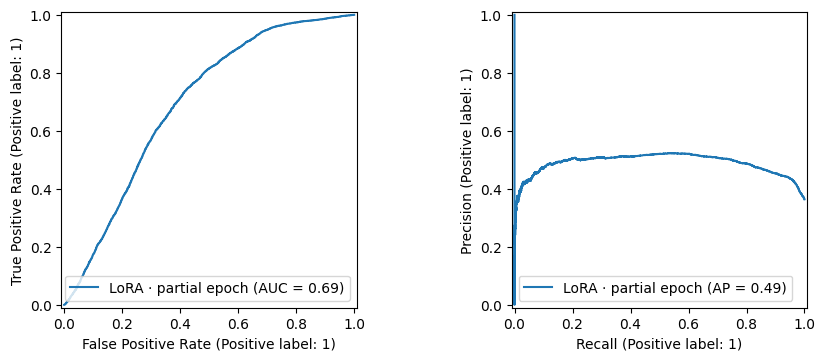

In [5]:
q11.show_results()

In [6]:
q11.export_comparison()

## Conclusion

Computed from the completed partial-epoch run and full validation.

In [7]:
q11.show_conclusion()

**Conclusion.** The partial-epoch LoRA run trained on **24,576** variants (52.4% of the frozen training pool), in 42.6 minutes through evaluation. On all **17,927** validation variants, AUROC was **0.693** (95% interval [0.675, 0.711]) and average precision was **0.487** (95% interval [0.435, 0.536]). User-authorized partial-epoch training for a one-hour run; full frozen validation is retained. No fitted frozen baseline or improvement claim; these are development results. Pretraining sequence exposure, homology and shared-patient overlap remain unresolved. The final attention block is numerically inactive in this BF16 configuration; LoRA targets the preceding Hyena mixer. No clinical validity or independent final-test performance is established.